# Data prep

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_ga_output = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')
df_gpt_output = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')

df_gpt_output = df_gpt_output.rename(columns={'smiles_A': 'smiles'})
df_original = df_original[df_original['chain_size'] == 0]

scaler = MinMaxScaler()
scaler.fit(df_original[['static_polarizability']])

df_ga_output['static_polarizability_pred_original'] = scaler.inverse_transform(df_ga_output[['static_polarizability']])

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors

def get_precise_vdw_volume(smiles):
    if pd.isna(smiles):
        return None
        
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
        
    mol = Chem.AddHs(mol)
    
    params = AllChem.ETKDG()
    params.randomSeed = 42 
    success = AllChem.EmbedMolecule(mol, params)
    
    if success != 0:
        pass
        
    try:
        AllChem.UFFOptimizeMolecule(mol)
    except:
        pass
        
    try:
        dclv = rdMolDescriptors.DoubleCubicLatticeVolume(mol)
        return dclv.GetVDWVolume()
    except:
        pass

df_ga_output['vdw_volume'] = df_ga_output['smiles'].apply(get_precise_vdw_volume)
df_gpt_output['vdw_volume'] = df_gpt_output['smiles'].apply(get_precise_vdw_volume)

[13:31:55] Conflicting single bond directions around double bond at index 5.
[13:31:55]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:31:55] Conflicting single bond directions around double bond at index 5.
[13:31:55]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:31:55] Conflicting single bond directions around double bond at index 5.
[13:31:55]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:32:00] Conflicting single bond directions around double bond at index 19.
[13:32:00]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:32:10] Conflicting single bond directions around double bond at index 11.
[13:32:10]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:32:10] Conflicting single bond directions around double bond at index 8.
[13:32:10]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:32:11] Conflicting single bond direction

In [3]:
df_ga_output.to_csv('df_ga_output.csv', index=False)
df_gpt_output.to_csv('df_gpt_output.csv', index=False)

# Refractive index

In [33]:
import pandas as pd
import numpy as np

df_ga_output = pd.read_csv('df_ga_output.csv')
df_gpt_output = pd.read_csv('df_gpt_output.csv')

df_gpt_output = df_gpt_output[df_gpt_output['error'] <= 0.20]

In [35]:
def calculate_refractive_index(df, pol_col='static_polarizability_pred_original', vol_col='vdw_volume'):
    """
    Computes Lorentz-Lorentz refractive index.
    
    Formula:
      n_o^2 = [1 + 2 * A] / [1 - A]
      where A = (4*pi/3) * N * alpha
            alpha = static_polarizability * 0.14818471
            N = K / vdw_volume
            K = 0.68
    """
    K = 0.68
    PI = np.pi
    
    N = K / df[vol_col]
    
    alpha = df[pol_col] * 0.14818471
    
    A = (4 * PI / 3) * N * alpha
    
    n_squared = (1 + 2 * A) / (1 - A)
    
    n_o = np.sqrt(n_squared)
    
    return n_o

df_ga_output['refractive_index'] = calculate_refractive_index(df_ga_output, pol_col='static_polarizability_pred_original', vol_col='vdw_volume')
df_gpt_output['refractive_index'] = calculate_refractive_index(df_gpt_output, pol_col='static_polarizability_pred_original', vol_col='vdw_volume')
df_ga_output = df_ga_output.drop_duplicates(subset='smiles')
df_gpt_output = df_gpt_output.drop_duplicates(subset='smiles')

/home/jgduarte/Documents/RA/Projects/3M/PolyGraphPy/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


# plots

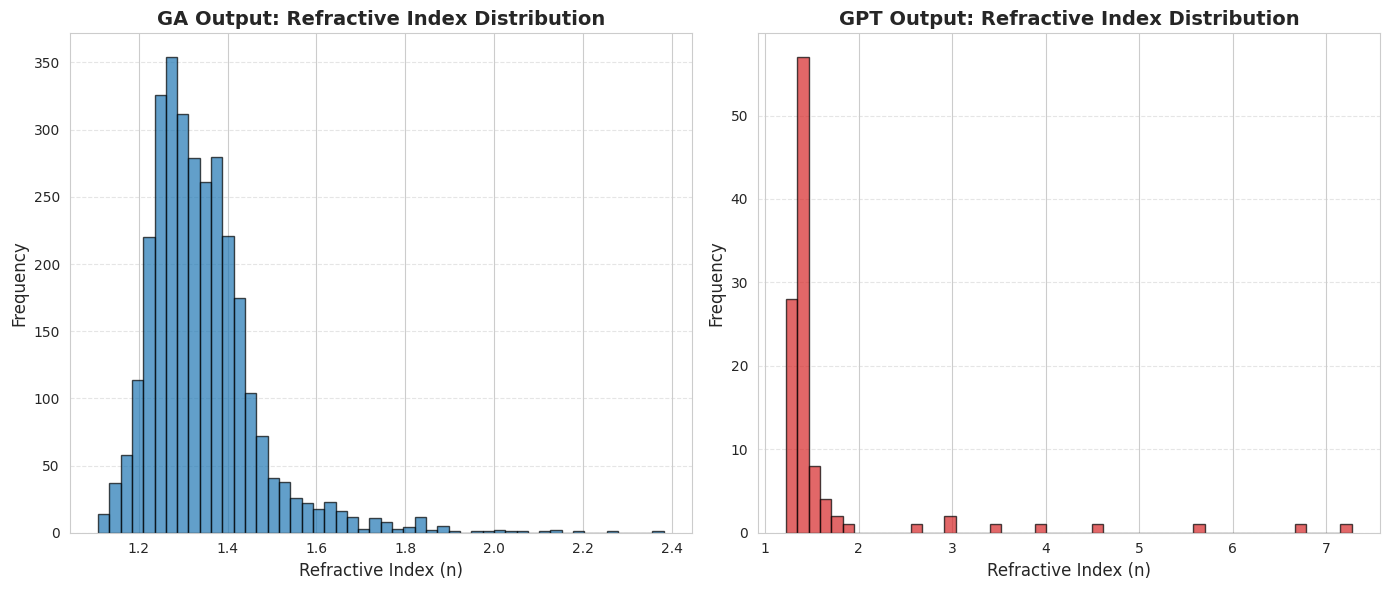

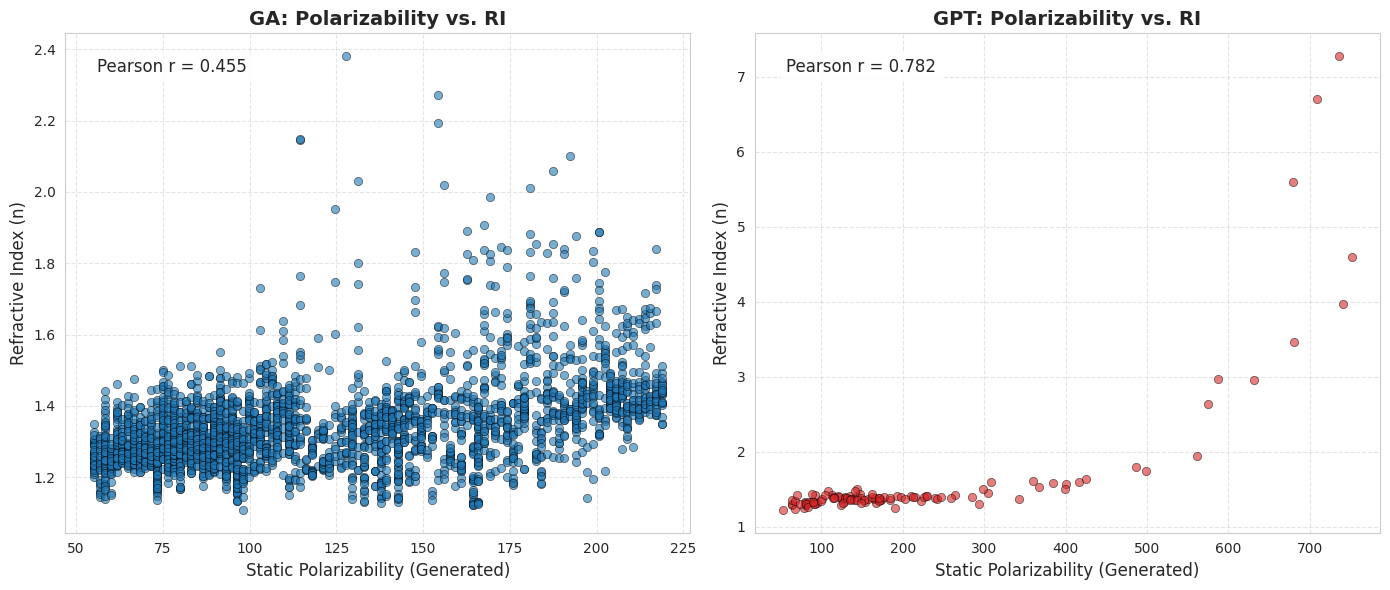

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Define a consistent style/color scheme manually since we aren't using seaborn
GA_COLOR = '#1f77b4'  # Standard matplotlib blue
GPT_COLOR = '#d62728' # Standard matplotlib red
ALPHA_VAL = 0.6       # Transparency for scatter points

# ==========================================
# 1. Histograms (1x2 Grid)
# ==========================================
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))

# --- GA Output Histogram ---
# Drop NaNs to avoid plotting errors
ga_ri = df_ga_output['refractive_index'].dropna()
axes1[0].hist(ga_ri, bins=50, color=GA_COLOR, alpha=0.7, edgecolor='black')
axes1[0].set_title('GA Output: Refractive Index Distribution', fontsize=14, fontweight='bold')
axes1[0].set_xlabel('Refractive Index (n)', fontsize=12)
axes1[0].set_ylabel('Frequency', fontsize=12)
axes1[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- GPT Output Histogram ---
gpt_ri = df_gpt_output['refractive_index'].dropna()
axes1[1].hist(gpt_ri, bins=50, color=GPT_COLOR, alpha=0.7, edgecolor='black')
axes1[1].set_title('GPT Output: Refractive Index Distribution', fontsize=14, fontweight='bold')
axes1[1].set_xlabel('Refractive Index (n)', fontsize=12)
axes1[1].set_ylabel('Frequency', fontsize=12)
axes1[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 2. Scatter Plots with Correlation (1x2 Grid)
# ==========================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

def plot_scatter_mpl(df, x_col, y_col, ax, title, color):
    # Filter valid data for correlation calculation
    valid_data = df.dropna(subset=[x_col, y_col])
    x = valid_data[x_col]
    y = valid_data[y_col]
    
    # Plot
    ax.scatter(x, y, alpha=ALPHA_VAL, c=color, edgecolor='k', linewidth=0.5)
    
    # Calculate Correlation
    if len(x) > 1:
        corr, _ = pearsonr(x, y)
        # Add text box
        text_str = f'Pearson r = {corr:.3f}'
        props = dict(boxstyle='round', facecolor='white', alpha=0.9)
        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)
    
    # Labels
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Static Polarizability (Generated)', fontsize=12)
    ax.set_ylabel('Refractive Index (n)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

# --- GA Scatter ---
plot_scatter_mpl(
    df_ga_output, 
    'static_polarizability_pred_original', 
    'refractive_index', 
    axes2[0], 
    'GA: Polarizability vs. RI', 
    GA_COLOR
)

# --- GPT Scatter ---
plot_scatter_mpl(
    df_gpt_output, 
    'static_polarizability_pred_original', 
    'refractive_index', 
    axes2[1], 
    'GPT: Polarizability vs. RI', 
    GPT_COLOR
)

plt.tight_layout()
plt.show()